In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)
from xgboost import XGBClassifier

print("✓ All libraries loaded!")


✓ All libraries loaded!


In [14]:
# ── Load CSF Biomarker Data ──────────────────────────────────────────────────
df_csf = pd.read_csv('investigator_fcsf_nacc71.csv', low_memory=False)
cols_csf = ['NACCID', 'CSFABYR', 'CSFLPYR', 'CSFABETA', 'CSFPTAU', 'CSFTTAU']
df_csf = df_csf[cols_csf].copy()
df_csf['CSFABYR'] = df_csf['CSFABYR'].fillna(df_csf['CSFLPYR'])  # fallback year
df_csf = df_csf.drop(columns=['CSFLPYR'])
df_csf = df_csf.rename(columns={'CSFABYR': 'YEAR'})

print(f"CSF dataset:      {df_csf.shape[0]:,} rows")

# ── Load Clinical Data (only columns needed) ─────────────────────────────────
df_clin = pd.read_csv('investigator_ftldlbd_nacc71.csv',
                       usecols=['NACCID', 'VISITYR', 'NACCUDSD', 'NACCAGE', 'SEX', 'EDUC', 'NACCAPOE'],
                       low_memory=False)
df_clin = df_clin.rename(columns={'VISITYR': 'YEAR', 'SEX': 'NACCSEX'})

print(f"Clinical dataset: {df_clin.shape[0]:,} rows")

# ── Merge on NACCID + YEAR ───────────────────────────────────────────────────
df_merged = pd.merge(df_csf, df_clin, on=['NACCID', 'YEAR'], how='inner')

print(f"Merged dataset:   {df_merged.shape[0]:,} rows × {df_merged.shape[1]} columns")
print("✓ Datasets merged successfully!")

CSF dataset:      3,051 rows
Clinical dataset: 205,908 rows
Merged dataset:   1,995 rows × 10 columns
✓ Datasets merged successfully!


In [15]:
# NACCUDSD: 1=Normal, 2=Impaired-not-MCI, 3=MCI, 4=AD Dementia
# Keep only Normal (1) vs AD (4) for clean binary classification
df_model = df_merged[df_merged['NACCUDSD'].isin([1, 4])].copy()
df_model['target'] = (df_model['NACCUDSD'] == 4).astype(int)

print("Target Distribution:")
print(f"  Normal (0): {(df_model['target']==0).sum():,}")
print(f"  AD     (1): {(df_model['target']==1).sum():,}")
print(f"  AD Prevalence: {df_model['target'].mean()*100:.2f}%")
print("\n✓ Target variable created!")


Target Distribution:
  Normal (0): 1,093
  AD     (1): 606
  AD Prevalence: 35.67%

✓ Target variable created!


In [16]:
features = ['CSFABETA', 'CSFPTAU', 'CSFTTAU', 'NACCAGE', 'NACCSEX', 'EDUC', 'NACCAPOE']

X = df_model[features].copy()
y = df_model['target'].copy()

# Impute missing with median
missing = X.isnull().sum()
missing = missing[missing > 0]
if len(missing):
    print("Missing values (filled with median):")
    for col, cnt in missing.items():
        print(f"  {col}: {cnt:,} ({cnt/len(X)*100:.1f}%)")
X = X.fillna(X.median())

print(f"\nDataset Shape: {X.shape[0]:,} patients × {X.shape[1]} features")
print(f"Features: {features}")
print("\n✓ Data preparation complete!")


Missing values (filled with median):
  CSFPTAU: 194 (11.4%)
  CSFTTAU: 106 (6.2%)

Dataset Shape: 1,699 patients × 7 features
Features: ['CSFABETA', 'CSFPTAU', 'CSFTTAU', 'NACCAGE', 'NACCSEX', 'EDUC', 'NACCAPOE']

✓ Data preparation complete!


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]:,} | Test set: {X_test.shape[0]:,}")
print("✓ Split & standardisation complete!")


Training set: 1,359 | Test set: 340
✓ Split & standardisation complete!


In [18]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    eval_metric='logloss',
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train_scaled, y_train,
                         cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"XGBoost 5-Fold CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")
print("✓ Cross-validation complete!")


XGBoost 5-Fold CV ROC-AUC: 0.8993 ± 0.0303
✓ Cross-validation complete!


In [19]:
print("🔍 Running GridSearchCV...")
print("   (This may take a few minutes...)\n")

param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.10],
    'max_depth':     [3, 4],
    'subsample':     [0.8, 1.0],
}
grid_search = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_scaled, y_train)
model = grid_search.best_estimator_

print(f"\n✓ Best parameters: {grid_search.best_params_}")
print(f"  Best CV AUC:     {grid_search.best_score_:.4f}")


🔍 Running GridSearchCV...
   (This may take a few minutes...)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

✓ Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
  Best CV AUC:     0.9020


In [20]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Normal", "Alzheimer's"]))


Accuracy: 0.8441176470588235
              precision    recall  f1-score   support

      Normal       0.87      0.89      0.88       219
 Alzheimer's       0.79      0.77      0.78       121

    accuracy                           0.84       340
   macro avg       0.83      0.83      0.83       340
weighted avg       0.84      0.84      0.84       340



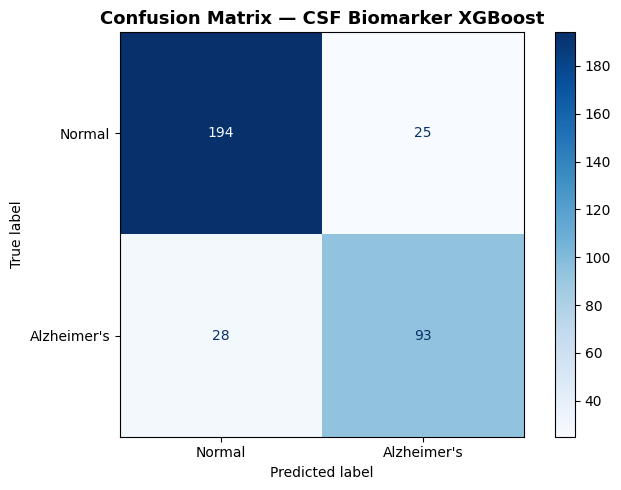

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Normal", "Alzheimer's"],
    cmap='Blues', ax=ax
)
ax.set_title("Confusion Matrix — CSF Biomarker XGBoost",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


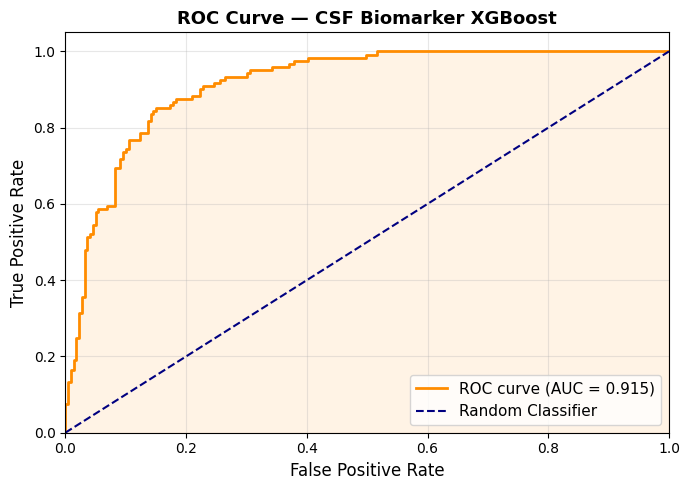

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2,
        label=f'ROC curve (AUC = {roc_auc_val:.3f})')
ax.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax.plot([0, 1], [0, 1], 'navy', lw=1.5, linestyle='--',
        label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title("ROC Curve — CSF Biomarker XGBoost",
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Feature Importance Ranking:
 Feature  Importance
CSFABETA    0.339062
 CSFTTAU    0.159468
 CSFPTAU    0.158021
    EDUC    0.094257
 NACCSEX    0.093932
 NACCAGE    0.082799
NACCAPOE    0.072460


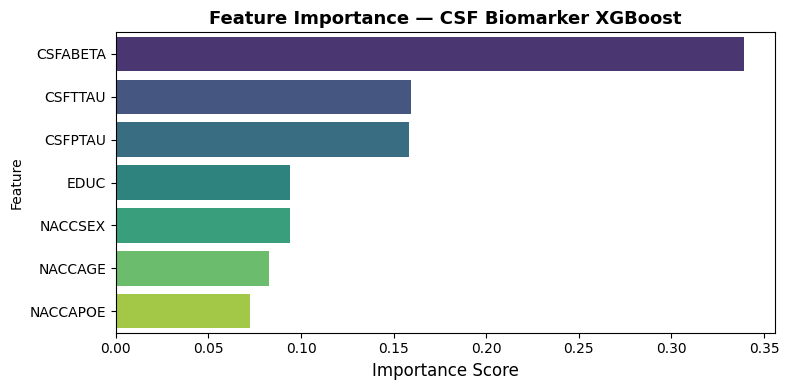

In [23]:
feat_df = pd.DataFrame({
    'Feature':    features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance Ranking:")
print(feat_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis', ax=ax)
ax.set_title("Feature Importance — CSF Biomarker XGBoost",
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()


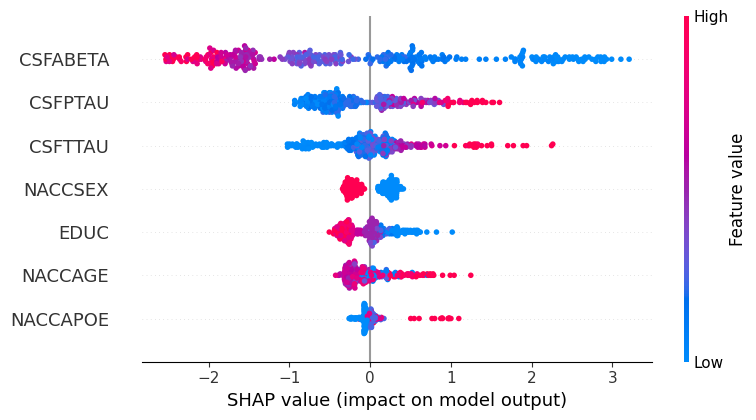

✓ SHAP summary plot shown!


In [24]:
try:
    import shap
    import matplotlib.pyplot as plt

    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_scaled[:500])

    plt.figure()
    shap.summary_plot(shap_values, X_test_scaled[:500],
                      feature_names=features, show=True)
    print("✓ SHAP summary plot shown!")
except ImportError:
    print("⚠ SHAP not installed. Run: pip install shap")
except Exception as e:
    print(f"⚠ SHAP error: {e}")


In [25]:
joblib.dump(model,    'biomarker_xgb_model.pkl')
joblib.dump(scaler,   'biomarker_scaler.pkl')
joblib.dump(features, 'biomarker_features.pkl')

print("✓ Model saved:")
print("  📁 biomarker_xgb_model.pkl")
print("  📁 biomarker_scaler.pkl")
print("  📁 biomarker_features.pkl")


✓ Model saved:
  📁 biomarker_xgb_model.pkl
  📁 biomarker_scaler.pkl
  📁 biomarker_features.pkl
